In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
!pip install selectivesearch
!pip install torch_snippets

In [19]:
import selectivesearch, pandas as pd, matplotlib.pyplot as plt, numpy as np, cv2
from torchvision import transforms, models, datasets
from torch_snippets import Report
from torchvision.ops import nms
from torch_snippets import *
from torch.utils.data import Dataset

In [ ]:
from google.colab import files
files.upload() # kaggle json

In [5]:
# make kaggle directory
!mkdir -p ~/.kaggle/
# move kaggle json file here
!mv kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
# download kaggle datasets
!kaggle datasets download -d sixhky/open-images-bus-trucks
# unzip downloaded data
!unzip -qq open-images-bus-trucks.zip

Dataset URL: https://www.kaggle.com/datasets/sixhky/open-images-bus-trucks
License(s): unknown
 81% 296M/367M [00:00<00:00, 861MB/s] 
100% 367M/367M [00:00<00:00, 730MB/s]


## Dataset Preparation

In [14]:
# dataset paths
images_root = "/content/images/images"
df_raw = pd.read_csv("/content/df.csv")

In [15]:
df_raw.head(2)

,ImageID,Source,LabelName,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,...,IsDepiction,IsInside,XClick1X,XClick2X,XClick3X,XClick4X,XClick1Y,XClick2Y,XClick3Y,XClick4Y
0,0000599864fd15b3,xclick,Bus,1,0.343750,0.90875,0.156162,0.650047,1,0,...,0,0,0.421875,0.343750,0.7950,0.908750,0.156162,0.512700,0.650047,0.457197
1,00006bdb1eb5cd74,xclick,Truck,1,0.276667,0.69750,0.141604,0.437343,1,0,...,0,0,0.299167,0.276667,0.6975,0.659167,0.141604,0.241855,0.352130,0.437343


XMin, XMax, YMin, YMax are ground truth bounding boxes

LabelName is class label for each object

In [43]:
class OpenImages(Dataset):
  def __init__(self, df , image_folder=images_root):
    self.root = image_folder
    self.df = df
    self.unique_images = df['ImageID'].unique()

  def __len__(self):
    return len(self.unique_images)

  # retrieve images , one by one
  def __getitem__(self, ix):
    image_id = self.unique_images[ix]
    image_path = f"{self.root}/{image_id}.jpg"
    # open image and covert to rgb
    image = cv2.imread(image_path, 1)[...,::-1]
    h, w, _ = image.shape
    df = self.df.copy()
    df = df[df['ImageID'] == image_id]
    # bounding boxes
    boxes = df['XMin,YMin,XMax,YMax'.split(',')].values # no spaces between coordinates XMin,YMin,XMax,YMax
    boxes = (boxes * np.array([w, h, w, h])).astype(np.uint16).tolist()
    # class names
    classes = df['LabelName'].values.tolist()
    return image, boxes, classes, image_path

In [44]:
# get data using class OpenImages
ds = OpenImages(df=df_raw, image_folder=images_root)

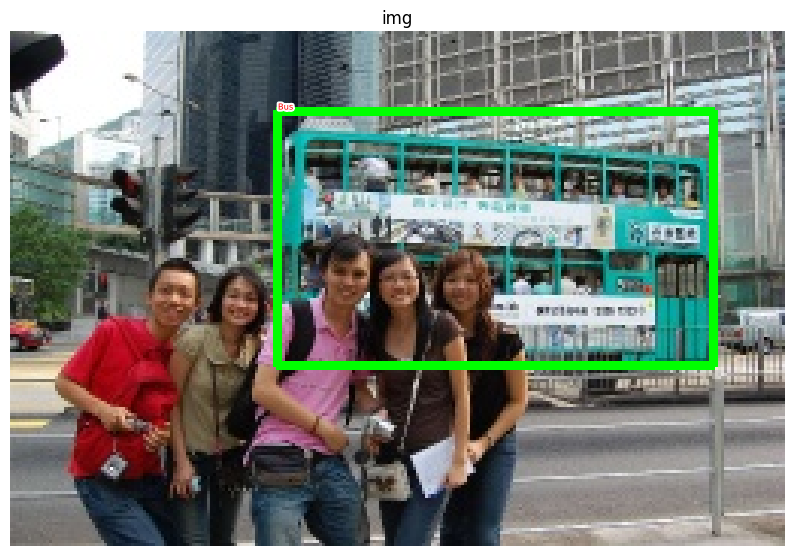

In [48]:
# inspect sample data
img, bbs, texts, _ = ds[0]
show(img, bbs=bbs, texts=texts, sz=10)